In [1]:
import os
import decode
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

c:\Users\bnort\miniconda3\envs\decode_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
start_iter = 100
end_iter = 400
frames_per_iter = 250

out_path = r'D:\Janelia_slm_data\processed\Janelia PALM RUN2'
out_csv = os.path.join(out_path, f'emitters_{start_iter}_{end_iter}_filtered.csv')
h5s_path = os.path.join(out_path, f'processed-2025-06-17')

#emitters = decode.EmitterSet.load(out_csv)
#print(emitters)

In [3]:
# create empty emitter set for loading
emitters = None
for i in tqdm(range(start_iter, end_iter), desc="Loading iterations"):
    out_h5 = os.path.join(h5s_path, f'iter_{i}.h5')
    #print(i, start_iter, end_iter)
    if emitters is None:
        emitters = decode.EmitterSet.load(out_h5)
        emitters.frame_ix += i * frames_per_iter
    else:
        emitters_ = decode.EmitterSet.load(out_h5)
        emitters_.frame_ix += i * frames_per_iter
        emitters = decode.EmitterSet.cat([emitters, emitters_])

Loading iterations: 100%|██████████| 300/300 [01:57<00:00,  2.55it/s]


C:\Users\bnort\AppData\Local\Temp\ipykernel_26648\3538920061.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitters.xyz_sig_nm[::sub_sample, 0].numpy())
C:\Users\bnort\AppData\Local\Temp\ipykernel_26648\3538920061.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitters.xyz_sig_nm[::su

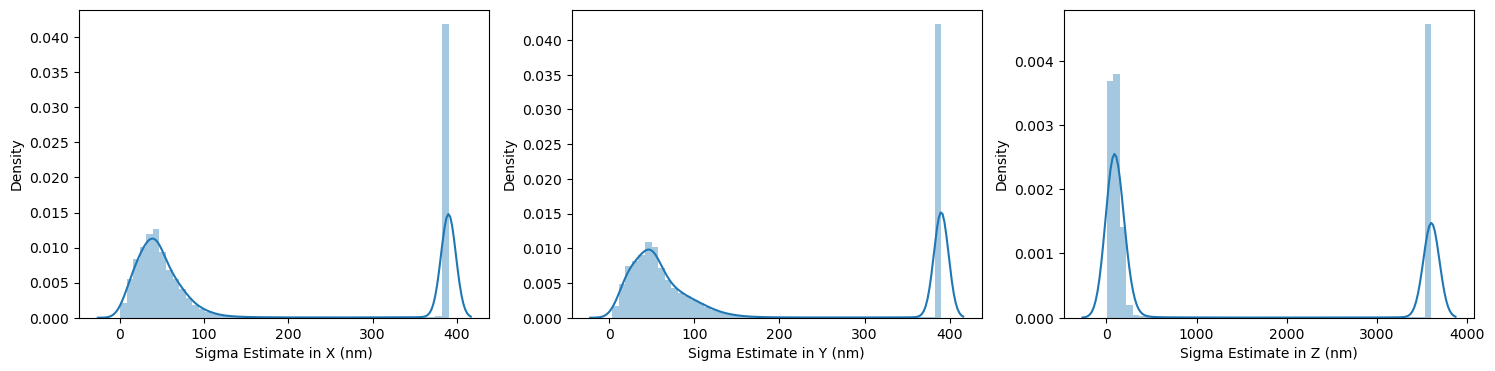

In [11]:
sub_sample = 25

plt.figure(figsize=(18,4))
plt.subplot(131)
sns.distplot(emitters.xyz_sig_nm[::sub_sample, 0].numpy())
plt.xlabel('Sigma Estimate in X (nm)')

plt.subplot(132)
sns.distplot(emitters.xyz_sig_nm[::sub_sample, 1].numpy())
plt.xlabel('Sigma Estimate in Y (nm)')

plt.subplot(133)
sns.distplot(emitters.xyz_sig_nm[::sub_sample, 2].numpy())
plt.xlabel('Sigma Estimate in Z (nm)')

plt.show()

In [17]:
print(emitters)
sigma_x_high_threshold = 200
sigma_y_high_threshold = 200
sigma_z_high_threshold = 500
prob_threshold = 0.5
coord_limit=((500,700),(100,200))
coord_limit=((0,500),(0,700))

print("0,1", coord_limit[0][0], coord_limit[0][1])

emitters_filtered = emitters[
    (emitters.xyz_sig_nm[:, 0] <= sigma_x_high_threshold)
    * (emitters.xyz_sig_nm[:, 1] <= sigma_x_high_threshold)
    * (emitters.xyz_sig_nm[:, 2] <= sigma_z_high_threshold)
    * (emitters.prob >= prob_threshold)
    ]

print(emitters_filtered)



EmitterSet
::num emitters: 54603329
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 25000 - 99999
::spanned volume: [-4.8509109e-01 -2.8965956e-01 -1.1998486e+03] - [ 799.4412   798.99884 1200.     ]
0,1 0 500
EmitterSet
::num emitters: 22545989
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 25000 - 99999
::spanned volume: [-4.8509109e-01  5.9604645e-08 -1.1414187e+03] - [ 799.4412   798.99884 1158.0946 ]


C:\Users\bnort\AppData\Local\Temp\ipykernel_33628\1852952606.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitters_filtered.xyz_sig_nm[:, 0].numpy())
C:\Users\bnort\AppData\Local\Temp\ipykernel_33628\1852952606.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitters_filtered.xyz_sig_

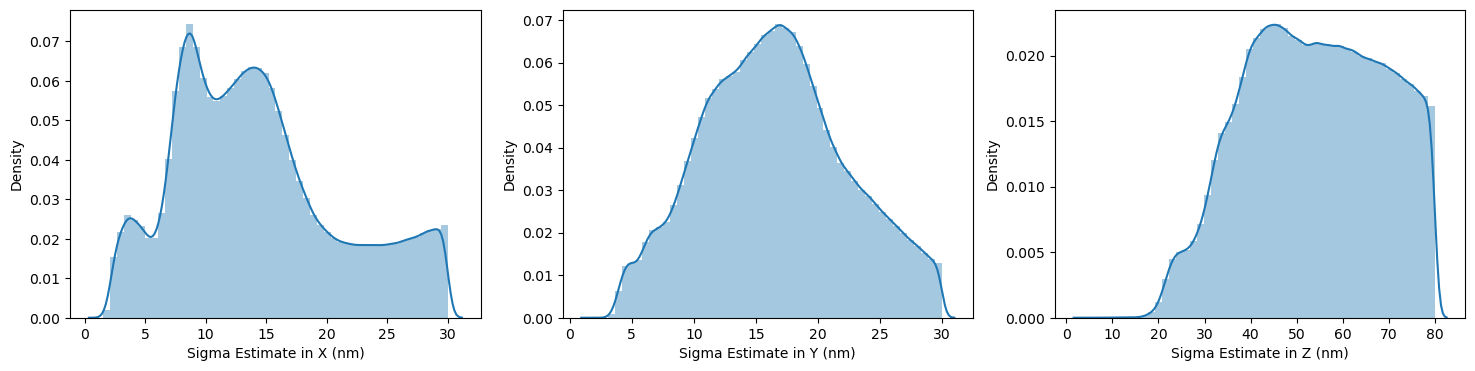

In [9]:
plt.figure(figsize=(18,4))
plt.subplot(131)
sns.distplot(emitters_filtered.xyz_sig_nm[:, 0].numpy())
plt.xlabel('Sigma Estimate in X (nm)')

plt.subplot(132)
sns.distplot(emitters_filtered.xyz_sig_nm[:, 1].numpy())
plt.xlabel('Sigma Estimate in Y (nm)')

plt.subplot(133)
sns.distplot(emitters_filtered.xyz_sig_nm[:, 2].numpy())
plt.xlabel('Sigma Estimate in Z (nm)')

plt.show()

In [18]:
emitters_filtered.frame_ix.min(), emitters_filtered.frame_ix.max(), 250*300
emitters_filtered.frame_ix = emitters_filtered.frame_ix - emitters_filtered.frame_ix.min()
emitters_filtered.frame_ix.min(), emitters_filtered.frame_ix.max(), 250*300


(tensor(0), tensor(74999), 75000)

In [19]:
out_csv = os.path.join(out_path, f'emitters_{start_iter}_{end_iter}_filtered_{sigma_x_high_threshold}_{sigma_y_high_threshold}_{sigma_z_high_threshold}.csv')
print(f'saving {out_csv}')
emitters_filtered.save(out_csv)

saving D:\Janelia_slm_data\processed\Janelia PALM RUN2\emitters_100_400_filtered_200_200_500.csv


In [11]:
emitters.frame_ix

tensor([25000, 25000, 25000,  ..., 57499, 57499, 57499])

In [12]:
emitters.frame_ix = emitters.frame_ix - emitters.frame_ix.min()
emitters.frame_ix

tensor([    0,     0,     0,  ..., 32499, 32499, 32499])

In [13]:
emitters_filtered.frame_ix = emitters_filtered.frame_ix - emitters_filtered.frame_ix.min()
emitters_filtered.frame_ix

tensor([    0,     0,     0,  ..., 32499, 32499, 32499])